# 第6章 Blackjack：遊び終えてから学ぶ（モンテカルロ法）

トランプのブラックジャックで、ディーラー（親）と1対1で勝負します。手札の合計を 21 に近づけたほうが勝ちで、21 を超えたら（バースト）負けです。2〜10 の札はその数字、絵札（J・Q・K）は 10 と数えます。A は、11 と数えても 21 を超えないなら 11、超えるなら 1 と数えます。プレイヤーは、最初に2枚、ディーラーは表向きの1枚と裏向きの1枚を配られます。プレイヤーは、ディーラーの表向きの1枚を見ながら、もう1枚引く（**HIT**）か、止める（**STICK**）かを選びます。止めると、ディーラーが裏の札を見せ、合計が 17 以上になるまで引きます。勝てば報酬 +1、引き分けは 0、負ければ -1 で、それまでの報酬はすべて 0 です。

第3〜5章の環境と違うのは、結果に **偶然** が入ることと、報酬が **勝負の最後にしか出ない** ことです。同じ手札で同じ選択をしても、次に引く札しだいで、勝つことも負けることもあります。この章では、**モンテカルロ法** を扱います。第3〜5章の Q学習・SARSA は、1歩ごとに、次の状態の Q 値の見積もりを使って表を書き換えました。モンテカルロ法は、エピソードを最後まで遊んでから、実際に得た報酬の合計で表を書き換えます。たくさん遊んで、その平均を表に覚えさせるやり方です。まず、モンテカルロ法のサンプルを動かして、学習した方策がどれだけ勝てるかを楽しみます。次に、サンプルを読み、最後に、ルールから計算した「答え」と比べます。

- **前提**: [第3章 FrozenLake](../ch03_frozenlake/ch03_frozenlake.ipynb)〜[第5章 Taxi](../ch05_taxi/ch05_taxi.ipynb)を終えていること
- **所要の目安**: 実行は CPU で 2〜3 分ほど
- **使う装置**: CPU だけで動きます（計算は NumPy だけです）

> **注記**
> - **出力の出どころ**: この Notebook に残っている出力は、著者の環境（Windows 11、CPU のみ、Gymnasium 1.3.0、NumPy 2.5.3）で 2026-10-10 に実行したものです。各セルの出力がそのまま期待する結果で、直後の「期待する結果」の段落に読み方を書いています。
> - **進め方**: セルを上から順に実行します。サンプルのプログラムは、読んで書き写す必要はありません。動かして、読んで、数字を変えて遊んでください。

## 0. 学習目標と完了条件

この章を終えると、次のことができるようになります。

1. Blackjack の観測（プレイヤーの合計・ディーラーの表向きの札・A を 11 と数えているか）・行動・報酬を説明できる
2. 用意したモンテカルロ法のサンプルを動かし、学習した方策の成績と、方策の地図と、対戦の様子を見られる
3. モンテカルロ法が「最後まで遊んでから、報酬の合計の平均で表を書き換える」ことが、サンプルのどの行に当たるかを説明できる
4. 学習した方策を、ルールから計算した最適な方策と比べ、違うマスがどんなマスかを説明できる

完了条件は、この Notebook を上から最後まで実行して、4節で学習した方策が、100,000 回の対戦で、ディーラーと同じ決まり（合計 17 以上で止める）の方策より、報酬の平均が高くなることです。

## 1. 全体像

この章の流れは次のとおりです。

| 節 | すること | 見るもの |
|---|---|---|
| 3節 | Blackjack を知る | 観測と手札、1回の勝負、決まった方策の成績 |
| 4節 | 動かして楽しむ：モンテカルロ法のサンプルを動かす | 学習後の成績、方策の地図、対戦の様子、学習曲線 |
| 5節 | 読む(1)：Q 表と、価値の見積もり | Q 表の中身、決まった方策の価値の地図 |
| 6節 | 読む(2)：サンプル | 最後まで遊ぶ部分、報酬の合計で書き換える部分 |
| 7節 | 比べる：ルールから計算した答え | 最適な方策の地図、学習後の方策と違うマス |
| 8節 | 遊んでみる | 学習の回数、カジノのルール |

この章のモンテカルロ法は、概要資料の[強化学習の手法の地図](../../overview/rl.md)の「表で覚える」領域にあります。第3〜5章の Q学習・SARSA と同じく、観測と行動の組み合わせごとの値（Q 値）を表に覚えますが、表の書き換え方が違います。

## 2. 準備

使うライブラリを読み込み、この章で何度も使う関数を用意します。

In [1]:
import time
from functools import cache
from pathlib import Path

import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from matplotlib.colors import ListedColormap

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

ACTION_NAMES = ["STICK", "HIT"]  # 行動の番号 0・1 の意味（止める・もう1枚引く）


# 札の数字 card の表示（Gymnasium の札は 1〜10 で、1 が A。絵札〈J・Q・K〉は 10 として配られる）
def card_label(card):
    return "A" if card == 1 else str(card)


# 手札 cards の合計と、A を 11 と数えているか（A があり、11 と数えても 21 を超えないなら 11 と数える）
def hand_sum(cards):
    total = sum(cards)
    if 1 in cards and total + 10 <= 21:
        return total + 10, True
    return total, False


# ディーラーの手札 dealer（上）とプレイヤーの手札 player（下）を描く。hidden=True ならディーラーの2枚目を裏向きにする
def draw_table(ax, player, dealer, hidden=True, title=None):
    ax.add_patch(plt.Rectangle((0, 0), 7.5, 4.0, facecolor="#2e7d4f"))
    for row_y, cards, is_dealer in [(2.2, dealer, True), (0.3, player, False)]:
        for i, card in enumerate(cards):
            back = is_dealer and hidden and i == 1
            ax.add_patch(plt.Rectangle((0.4 + i * 0.85, row_y), 0.7, 1.0,
                                       facecolor="#7a9cc6" if back else "white", edgecolor="black", lw=1.5))
            if not back:
                ax.text(0.75 + i * 0.85, row_y + 0.5, card_label(card), ha="center", va="center",
                        fontsize=14 if card < 10 else 11, fontweight="bold", color="tab:red" if card == 1 else "black")
    total, usable = hand_sum(player)
    ax.text(0.4, 1.45, f"player: {total}" + (" (usable ace)" if usable else ""), color="white", fontsize=11)
    dealer_text = f"dealer: shows {card_label(dealer[0])}" if hidden else f"dealer: {hand_sum(dealer)[0]}"
    ax.text(0.4, 3.35, dealer_text, color="white", fontsize=11)
    ax.set_xlim(0, 7.5)
    ax.set_ylim(0, 4.0)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)


# 合計が threshold 以上なら止め（0）、それ未満なら引く（1）方策を、観測 (合計, ディーラーの札, A を 11 と数えているか) で引ける表にする
def threshold_policy(threshold):
    policy = np.ones((32, 11, 2), dtype=int)
    policy[threshold:] = 0
    return policy


# 方策の表 policy に従って episodes 回対戦させ、報酬の平均と、勝ち・引き分け・負けの割合を返す（policy=None なら、でたらめに選ぶ）
def play(env, policy, episodes=100_000, seed=100):
    env.action_space.seed(seed)
    rewards = np.zeros(episodes)
    for i in range(episodes):
        obs, info = env.reset(seed=seed if i == 0 else None)
        while True:
            action = env.action_space.sample() if policy is None else int(policy[obs])
            obs, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                rewards[i] = reward
                break
    return rewards.mean(), (rewards > 0).mean(), (rewards == 0).mean(), (rewards < 0).mean()


# 方策の表 policy の、プレイヤーの合計 12〜21 の部分を描く（usable: A を 11 と数えているか。marks の True のマスを赤い枠で囲む）
def draw_policy(ax, policy, usable, title, marks=None):
    grid = policy[12:22, 1:11, usable]
    ax.imshow(grid, origin="lower", cmap=ListedColormap(["#f6e3a1", "#b6cdf2"]), vmin=0, vmax=1,
              extent=(0.5, 10.5, 11.5, 21.5))
    for player_sum in range(12, 22):
        for dealer_card in range(1, 11):
            ax.text(dealer_card, player_sum, "S" if policy[player_sum, dealer_card, usable] == 0 else "H",
                    ha="center", va="center", fontsize=9)
            if marks is not None and marks[player_sum, dealer_card, usable]:
                ax.add_patch(plt.Rectangle((dealer_card - 0.45, player_sum - 0.45), 0.9, 0.9,
                                           fill=False, edgecolor="tab:red", lw=2))
    ax.set_xticks(range(1, 11), [card_label(c) for c in range(1, 11)])
    ax.set_yticks(range(12, 22))
    ax.set_xlabel("dealer's card")
    ax.set_ylabel("player's sum")
    ax.set_title(title, fontsize=10)

関数の説明:

- `card_label` と `hand_sum` は、札の表示（1 を `A` と書く）と、手札の合計を求める関数です。`hand_sum` は、A を 11 と数えても 21 を超えないなら 11 と数えます。Gymnasium の中の計算と同じ決まりです
- `draw_table` は、ディーラーの手札（上）とプレイヤーの手札（下）を matplotlib で描く関数です。ディーラーの裏向きの札は青い四角で描き、A は赤い字で描きます
- `threshold_policy` は、「合計が決めた数以上なら止め、それ未満なら引く」方策を、観測で引ける表（配列）にする関数です。表の中身は行動の番号（0 が止める、1 が引く）です
- `play` は、方策の表に従って 100,000 回対戦させ、報酬の平均と、勝ち・引き分け・負けの割合を返す関数です。第5章の `evaluate` と同じく、最初の `reset` にだけ `seed` を渡します
- `draw_policy` は、方策の表を、横軸がディーラーの表向きの札、縦軸がプレイヤーの合計（12〜21）の地図に描く関数です。止めるマスを黄色に `S`、引くマスを青に `H` と書きます

Gymnasium にも Blackjack の絵を描く機能がありますが、これまでの章と同じく、その絵には Gymnasium のライセンスとは別の作者の画像素材（トランプの絵）が使われています。この章でも、その絵を載せずに、`draw_table` で描いた図を使います。

## 3. Blackjack を知る

### 3-1. 環境を作る

In [2]:
env = gym.make("Blackjack-v1")
print(env)
print("ルールの設定:", env.spec.kwargs)
print("エピソードの上限の回数:", env.spec.max_episode_steps)
print("観測の空間:", env.observation_space)
print("行動の空間:", env.action_space)

<OrderEnforcing<PassiveEnvChecker<BlackjackEnv<Blackjack-v1>>>>
ルールの設定: {'sab': True, 'natural': False}
エピソードの上限の回数: None
観測の空間: Tuple(Discrete(32), Discrete(11), Discrete(2))
行動の空間: Discrete(2)


**期待する結果**（上の出力の読み方）: 1行目から、本体の `BlackjackEnv` を2つのラッパーが包んでいることが分かります。第3章の FrozenLake・第5章の Taxi と違い、第4章の CliffWalking と同じく、`TimeLimit` はありません。エピソードの上限の回数も `None` です。ルールの設定は `sab=True`、`natural=False` です。

観測の空間は、3つの整数の組（`Tuple`）です。1つ目がプレイヤーの手札の合計（0〜31）、2つ目がディーラーの表向きの札（1〜10。1 が A）、3つ目が、プレイヤーが A を 11 と数えているか（1 なら数えている）です。行動の空間は `Discrete(2)` で、0 が止める（`STICK`）、1 がもう1枚引く（`HIT`）です。

`sab=True` は、教科書 Sutton と Barto の *Reinforcement Learning: An Introduction* の例と同じルールにする設定です。Gymnasium 1.3.0 のソースでは、`BlackjackEnv` そのものの既定は `sab=False` ですが、`gym.make("Blackjack-v1")` で作ると `sab=True` になるように登録されています。このルールでは、最初の2枚が A と 10 の札（**ナチュラル**）で止めれば、ディーラーもナチュラルでない限り勝ち（+1）、両方ナチュラルなら引き分けです。ほかのルールで遊ぶ方法は、8-2節で試します。

### 3-2. 最初に配られた札を見る

`reset` で最初の観測を受け取ります。プレイヤーには見えないディーラーの裏の札も、`env.unwrapped` から覗いて表示します。

観測: (11, 10, 0)
プレイヤーの手札: [7, 4]  ディーラーの手札: [10, 9]


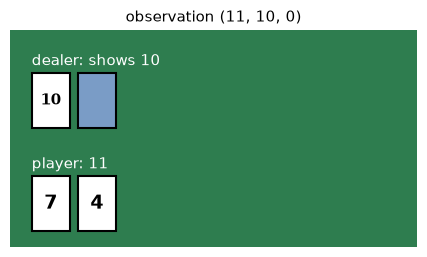

In [3]:
obs, info = env.reset(seed=0)
print("観測:", obs)
print("プレイヤーの手札:", env.unwrapped.player, " ディーラーの手札:", env.unwrapped.dealer)

fig, ax = plt.subplots(figsize=(4.5, 2.6))
draw_table(ax, env.unwrapped.player, env.unwrapped.dealer, title=f"observation {obs}")
fig.tight_layout()
fig.savefig(FIGURES / "ch06_table.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 最初の観測は `(11, 10, 0)` です。プレイヤーの手札は 7 と 4 で合計 11、ディーラーの表向きの札は 10、A は持っていないので 3つ目は 0 です。ディーラーの手札は 10 と 9 で、裏の 9 はプレイヤーには見えません。図では、上の段がディーラーの手札（2枚目が裏向きの青い四角）、下の段がプレイヤーの手札です。

Gymnasium 1.3.0 のソースによると、札は毎回、1〜10 の札の山から、使った札を戻して引きます（無限にある山から引くのと同じです）。1〜9 はそれぞれ確率 1/13、10 は 10・J・Q・K の4種類の分で確率 4/13 です。そのため、前に出た札を覚えても、次の札の手がかりにはなりません。

### 3-3. 1回勝負する

3-2節の続きを、「合計が 20 以上なら止め、それ未満なら引く」方策で遊びます。

In [4]:
policy_20 = threshold_policy(20)  # 合計が 20 以上なら止める方策
while True:
    action = int(policy_20[obs])
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"{ACTION_NAMES[action]:5s} → 観測 {obs}、報酬 {reward}、terminated={terminated}")
    if terminated or truncated:
        break
print("プレイヤーの手札:", env.unwrapped.player, " ディーラーの手札:", env.unwrapped.dealer)

HIT   → 観測 (12, 10, 0)、報酬 0.0、terminated=False
HIT   → 観測 (13, 10, 0)、報酬 0.0、terminated=False
HIT   → 観測 (16, 10, 0)、報酬 0.0、terminated=False
HIT   → 観測 (26, 10, 0)、報酬 -1.0、terminated=True
プレイヤーの手札: [7, 4, 1, 1, 3, 10]  ディーラーの手札: [10, 9]


**期待する結果**（上の出力の読み方）: 合計 11 から引き続けます。1枚目の A で観測は `(12, 10, 0)` になります。A を 11 と数えると 22 で 21 を超えるので、A は 1 と数えられ、3つ目は 0 のままです。2枚目も A で 13、3 で 16、10 で 26 になってバーストし、報酬 -1 で終わりました（`terminated=True`）。途中の報酬は、どれも 0 です。

最後のディーラーの手札は、最初と同じ 10 と 9 のままです。プレイヤーがバーストすると、ディーラーが引く前に負けが決まります。

### 3-4. 決まった方策の成績を測る

3つの方策で、それぞれ 100,000 回対戦させます。でたらめに選ぶ方策、3-3節の「20 以上で止める」方策、ディーラーと同じ「17 以上で止める」方策です。著者の環境では、このセル全体で 30 秒ほどかかりました。

In [5]:
policy_17 = threshold_policy(17)  # 合計が 17 以上なら止める方策（ディーラーと同じ決まり）
results = {}
for name, policy in [("でたらめ", None), ("20 以上で止める", policy_20), ("17 以上で止める", policy_17)]:
    results[name] = play(env, policy)
    mean, win, draw, lose = results[name]
    print(f"{name:10s} 報酬の平均 {mean:7.3f}、勝ち {win:.1%}、引き分け {draw:.1%}、負け {lose:.1%}")

でたらめ       報酬の平均  -0.399、勝ち 28.0%、引き分け 4.1%、負け 67.9%


20 以上で止める  報酬の平均  -0.355、勝ち 29.5%、引き分け 5.5%、負け 65.0%


17 以上で止める  報酬の平均  -0.075、勝ち 41.1%、引き分け 10.3%、負け 48.6%


**期待する結果**（上の出力の読み方）: でたらめに選ぶと、報酬の平均は -0.399 で、勝ちは 28.0%、負けは 67.9% です。「20 以上で止める」方策は -0.355 で、でたらめとの差は 0.044 です。「17 以上で止める」方策は -0.075 で、勝ちが 41.1% まで上がりますが、負け（48.6%）のほうが多いままです。

ディーラーと同じ決まりで引いても、勝ちより負けが多くなりました。なお、ルールでは、プレイヤーが先にバーストすると、ディーラーが引く前に負けが決まります（3-3節）。4節では、ディーラーの表向きの札や、A を 11 と数えているかに応じて止めるか引くかを変える方策を、モンテカルロ法で学ばせます。

## 4. 動かして楽しむ：モンテカルロ法のサンプルを動かす

### 4-1. 学習させる

用意したモンテカルロ法のサンプルで、200,000 回勝負させます。ε（でたらめに選ぶ確率）は、第3・4章と同じく 0.1 で一定です。サンプルの中身は6節で読むので、ここでは実行して結果を見てください。著者の環境では 25 秒ほどかかりました。

In [6]:
# Q 値が最大の行動を1つ返す（最大が複数あれば、でたらめに選ぶ）
def greedy_action(q_table, obs, rng):
    values = q_table[obs]
    best = np.flatnonzero(values == values.max())
    return int(rng.choice(best))


# ε-greedy のモンテカルロ制御で episodes 回のエピソードを経験させ、Q 表と、平均した回数の表と、エピソードごとの報酬を返す
def mc_control(env, episodes, epsilon=0.1, gamma=1.0, seed=0):
    rng = np.random.default_rng(seed)
    q_table = np.zeros((32, 11, 2, 2))  # 観測 (合計, ディーラーの札, A を 11 と数えているか) × 行動
    counts = np.zeros_like(q_table)  # 各 (観測, 行動) で、報酬の合計を何回平均したか
    rewards = np.zeros(episodes)
    for i in range(episodes):
        # 1. エピソードを最後まで遊び、(観測, 行動, 報酬) を記録する
        obs, info = env.reset(seed=seed if i == 0 else None)
        episode = []
        while True:
            if rng.random() < epsilon:  # 探索: でたらめに選ぶ
                action = int(rng.integers(2))
            else:  # 活用: Q 値が最大の行動を選ぶ
                action = greedy_action(q_table, obs, rng)
            next_obs, reward, terminated, truncated, info = env.step(action)
            episode.append((obs, action, reward))
            obs = next_obs
            if terminated or truncated:
                break
        # 2. 後ろから順に、その時点から最後までの報酬の合計 G を求め、Q 値を G の平均に近づける
        G = 0.0
        for obs, action, reward in reversed(episode):
            G = gamma * G + reward
            counts[obs + (action,)] += 1
            q_table[obs + (action,)] += (G - q_table[obs + (action,)]) / counts[obs + (action,)]
        rewards[i] = G
    return q_table, counts, rewards


start = time.perf_counter()
q_table, counts, train_rewards = mc_control(env, episodes=200_000)
print(f"学習にかかった時間: {time.perf_counter() - start:.1f} 秒")
print(f"学習中、最初の 10,000 回の報酬の平均: {train_rewards[:10_000].mean():7.3f}")
print(f"学習中、最後の 10,000 回の報酬の平均: {train_rewards[-10_000:].mean():7.3f}")

学習にかかった時間: 24.4 秒
学習中、最初の 10,000 回の報酬の平均:  -0.152
学習中、最後の 10,000 回の報酬の平均:  -0.092


**期待する結果**（上の出力の読み方）: 学習は著者の環境で 24.4 秒でした（パソコンによって変わります）。学習中の報酬の平均は、最初の 10,000 回の -0.152 から、最後の 10,000 回の -0.092 まで上がりました。

学習の seed（`mc_control` の `seed=0`）と、環境の最初の `reset` の seed を固定しているので、同じ版のライブラリなら、時間以外は何度実行しても同じ結果になります。γ（割引率）は、第4章と同じ 1.0（割り引かない）です。学習中の報酬には、でたらめに選んだ行動の分も含まれます（第3章の4-4節）。

### 4-2. 成績を測る

学習した Q 表から、観測ごとに Q 値が大きいほうの行動を選ぶ方策の表を作り、3-4節と同じく 100,000 回対戦させます。学習中とは違い、でたらめな行動は混ぜません。

In [7]:
learned_policy = q_table.argmax(axis=-1)  # 観測ごとに Q 値が大きいほうの行動（同じなら止める）
results["学習後の方策"] = play(env, learned_policy)
for name in ["17 以上で止める", "学習後の方策"]:
    mean, win, draw, lose = results[name]
    print(f"{name:10s} 報酬の平均 {mean:7.3f}、勝ち {win:.1%}、引き分け {draw:.1%}、負け {lose:.1%}")

17 以上で止める  報酬の平均  -0.075、勝ち 41.1%、引き分け 10.3%、負け 48.6%
学習後の方策     報酬の平均  -0.052、勝ち 43.2%、引き分け 8.4%、負け 48.4%


**期待する結果**（上の出力の読み方）: 学習後の方策の報酬の平均は -0.052 で、「17 以上で止める」方策（-0.075）より高く、この章の完了条件を満たしています。勝ちは 41.1% から 43.2% に増え、負けは 48.6% から 48.4% に減りました。それでも、報酬の平均はマイナスのままです。

どこまで勝てれば一番よいのかは、7節で、ルールから計算した最適な方策と比べて確かめます。

### 4-3. 方策の地図を見る

学習後の方策の表を、`draw_policy` で地図にします。左が A を 11 と数えていない場合、右が数えている場合です。

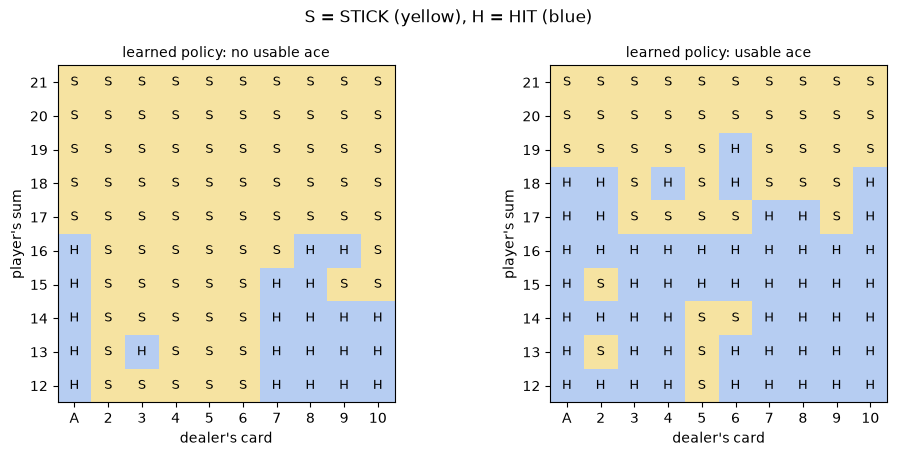

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
draw_policy(axes[0], learned_policy, 0, "learned policy: no usable ace")
draw_policy(axes[1], learned_policy, 1, "learned policy: usable ace")
fig.suptitle("S = STICK (yellow), H = HIT (blue)")
fig.tight_layout()
fig.savefig(FIGURES / "ch06_policy.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 左の地図（A を 11 と数えていない）では、合計 17 以上は、どのディーラーの札に対しても止めます（`S`）。合計 12〜16 では、ディーラーの札が 2〜6 のときはおおむね止め、7〜10 と A のときはおおむね引いています（`H`）。ただし、合計 13 でディーラーの札が 3 のマスは引き、合計 15 でディーラーの札が 9・10、合計 16 で 7・10 のマスは止めるなど、まわりと違うマスもあります。

右の地図（A を 11 と数えている）では、合計 19 以上はおおむね止め、合計 16 以下はおおむね引いています。合計 17・18 は、止めるマスと引くマスが混ざっています。

### 4-4. 対戦の様子を見る

学習後の方策で1回対戦させ、その様子を GIF に保存します。

HIT   → 観測 (14, 10, 0)、報酬 0.0
HIT   → 観測 (21, 10, 0)、報酬 0.0
STICK → 観測 (21, 10, 0)、報酬 1.0
プレイヤーの手札: [4, 6, 4, 7]  ディーラーの手札: [10, 4, 4]


GIF の枚数: 9


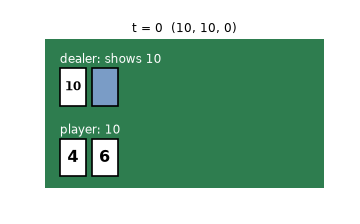

In [9]:
obs, info = env.reset(seed=20)
shots = [(list(env.unwrapped.player), list(env.unwrapped.dealer), True, f"t = 0  {obs}")]
while True:
    action = int(learned_policy[obs])
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"{ACTION_NAMES[action]:5s} → 観測 {obs}、報酬 {reward}")
    if action == 1:  # 引いた札を加えた手札
        shots.append((list(env.unwrapped.player), list(env.unwrapped.dealer[:2]), True, f"t = {len(shots)}  HIT"))
    if terminated or truncated:
        break
player, dealer = list(env.unwrapped.player), list(env.unwrapped.dealer)
print("プレイヤーの手札:", player, " ディーラーの手札:", dealer)
if action == 0:  # 止めたあと、ディーラーが2枚目を見せ、17 以上になるまで1枚ずつ引く
    for n in range(2, len(dealer) + 1):
        shots.append((player, dealer[:n], False, "STICK" if n == 2 else "dealer draws"))
result = {1.0: "WIN", 0.0: "DRAW", -1.0: "LOSE"}[reward]
shots.append((player, dealer, action == 1, f"{result} (reward {reward:+.0f})"))

frames = []
for player_cards, dealer_cards, hidden, label in shots:
    fig, ax = plt.subplots(figsize=(4.5, 2.8), dpi=80)
    draw_table(ax, player_cards, dealer_cards, hidden=hidden, title=label)
    fig.canvas.draw()
    frames.append(np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy())
    plt.close(fig)
imageio.v3.imwrite(FIGURES / "ch06_play.gif", frames + [frames[-1]] * 3, duration=1000, loop=0)
print("GIF の枚数:", len(frames) + 3)
Image(filename=FIGURES / "ch06_play.gif")

**期待する結果**（上の出力の読み方）: この回は、最初の手札が 4 と 6（合計 10）で、ディーラーの表向きの札は 10 でした。学習後の方策は2回引き、4 で 14、7 で 21 になって止めました。ディーラーの手札は 10 と 4（合計 14）で、17 に届かないのでもう1枚引き、4 で 18 になりました。21 対 18 で、プレイヤーの勝ち（報酬 1.0）です。

GIF には、場面ごとの図 6 枚（最初の手札、2回の HIT、止めてディーラーが裏の札を見せた所、ディーラーが引いた所、結果）に、最後の図を 3 枚足した 9 枚を書き込みます（結果の所で少し止めるため）。1 枚を 1 秒で表示します。

**期待する結果**（VS Code などで実行した場合）: 上の出力は、4-4節の対戦の GIF です。プレイヤーの手札が1枚ずつ増えて 21 になり、そのあとディーラーの裏の札が表になって、ディーラーが1枚引き、最後に `WIN (reward +1)` と表示されます。

GitHub でこの Notebook を読んでいる場合、上の出力の GIF の動きは見られません（著者が、private だった 2026-10-01 に第0章で、public にした後の 2026-10-10 に第3〜5章で確かめました）。GIF は、この章のフォルダの [README.md](README.md) でも見られます。Notebook の中でも見られるように、次のセルで、同じ対戦のコマ送りの図を作ります。

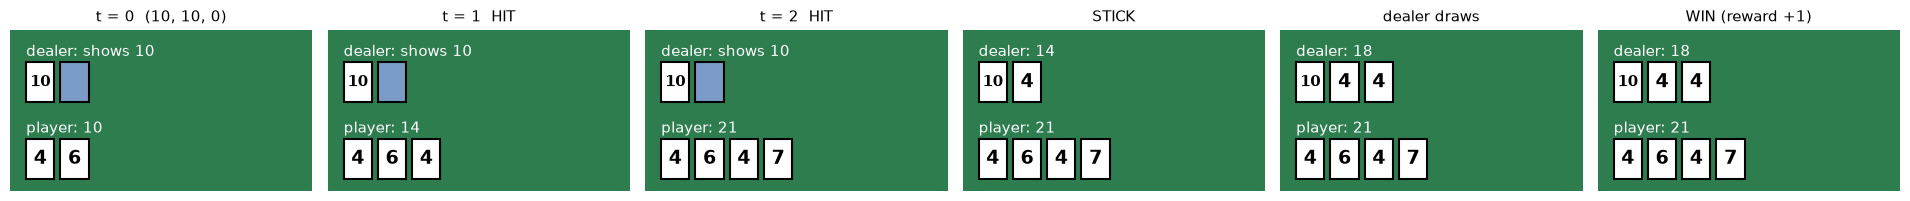

In [10]:
fig, axes = plt.subplots(1, len(shots), figsize=(3.2 * len(shots), 2.4))
for ax, (player_cards, dealer_cards, hidden, label) in zip(axes, shots):
    draw_table(ax, player_cards, dealer_cards, hidden=hidden, title=label)
fig.tight_layout()
fig.savefig(FIGURES / "ch06_play_frames.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 4-4節の対戦の、6 つの場面の図です。左から、最初の手札（題の `(10, 10, 0)` が観測）、1回目と2回目の `HIT`、止めてディーラーが裏の 4 を見せた所（`STICK`）、ディーラーが 4 を引いて 18 になった所、結果（`WIN`）です。ディーラーの裏の札は、プレイヤーが止めるまで青い四角のままです。

### 4-5. 学習曲線を見る

学習中の報酬を 10,000 回ずつに区切って平均した点（青）を、3-4節の「17 以上で止める」方策と、4-2節の学習後の方策の成績と並べて描きます。

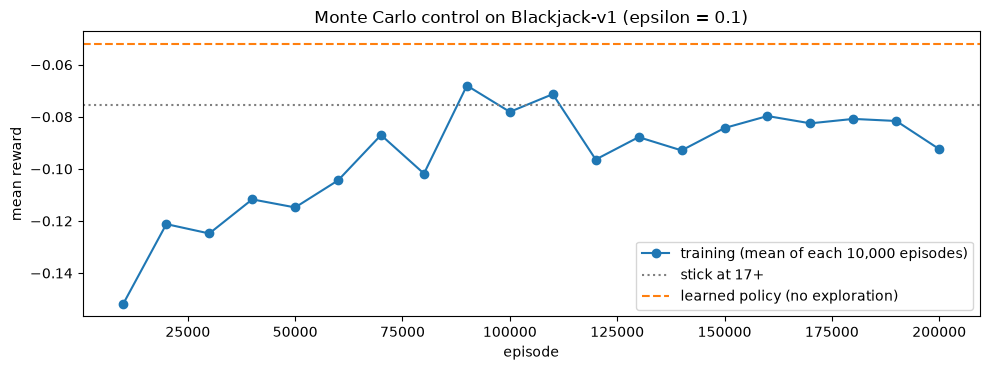

In [11]:
block = 10_000
block_means = train_rewards.reshape(-1, block).mean(axis=1)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(np.arange(1, len(block_means) + 1) * block, block_means, marker="o", color="tab:blue",
        label=f"training (mean of each {block:,} episodes)")
ax.axhline(results["17 以上で止める"][0], color="tab:gray", linestyle=":", label="stick at 17+")
ax.axhline(results["学習後の方策"][0], color="tab:orange", linestyle="--", label="learned policy (no exploration)")
ax.set_xlabel("episode")
ax.set_ylabel("mean reward")
ax.set_title("Monte Carlo control on Blackjack-v1 (epsilon = 0.1)")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "ch06_learning_curve.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 青い点は、10,000 回ずつの学習中の報酬の平均です。灰色の点線が「17 以上で止める」方策（-0.075）、橙の破線が、4-2節で測った学習後の方策（-0.052）です。

青い点は、最初の -0.15 あたりから上がり、90,000〜110,000 回あたりで -0.07 前後になります。そのあとは -0.10〜-0.08 の間を上下していて、橙の破線より下にあります。

青い点と橙の破線では、測り方が2つ違います。青い点は、0.1 の確率ででたらめな行動を混ぜ、学習の途中の Q 表で選んだ成績です。橙の破線は、でたらめを混ぜず、学習を終えた Q 表で選んで、100,000 回対戦させた成績です。また、1回の勝負の報酬は +1・0・-1 のどれかで、同じ方策でも偶然で変わります。

## 5. 読む(1)：Q 表と、価値の見積もり

### 5-1. Q 表を読む

4節で学んだ Q 表の形と、いくつかの観測の行を見ます。`counts` は、その観測と行動の組み合わせで、報酬の合計を何回平均したか（6節）を数えた表です。

In [12]:
print("Q 表の形:", q_table.shape)
for obs in [(20, 10, 0), (16, 10, 0), (12, 4, 0), (18, 9, 1)]:
    print(f"観測 {obs}: STICK {q_table[obs][0]:6.3f}（{counts[obs][0]:6,.0f} 回）、"
          f"HIT {q_table[obs][1]:6.3f}（{counts[obs][1]:6,.0f} 回） → {ACTION_NAMES[learned_policy[obs]]}")

Q 表の形: (32, 11, 2, 2)
観測 (20, 10, 0): STICK  0.432（ 8,353 回）、HIT -0.879（   446 回） → STICK
観測 (16, 10, 0): STICK -0.585（ 6,846 回）、HIT -0.599（   479 回） → STICK
観測 (12, 4, 0): STICK -0.200（ 1,632 回）、HIT -0.327（    98 回） → STICK
観測 (18, 9, 1): STICK -0.129（   272 回）、HIT -0.182（    11 回） → STICK


**期待する結果**（上の出力の読み方）: Q 表の形は `(32, 11, 2, 2)` です。前の3つが観測の3つの整数（合計 0〜31、ディーラーの札 0〜10、A を 11 と数えているか 0・1）、最後の 2 が行動（止める・引く）です。

- 合計 20、ディーラーの札 10 では、止めると 0.432、引くと -0.879 で、止めるほうが大きく上回っています
- 合計 16、ディーラーの札 10 では、止めると -0.585、引くと -0.599 で、どちらもマイナスで、差は 0.014 です
- 合計 12、ディーラーの札 4 では、止めると -0.200、引くと -0.327 です
- 合計 18 で A を 11 と数えていて、ディーラーの札が 9 では、止めると -0.129、引くと -0.182 です。引くほうは、11 回しか平均していません

4つとも、Q 値が大きいほうの止める（`STICK`）が、学習後の方策の行動です。

Q 値は、その観測でその行動を選び、そのあと学習中の方策（0.1 の確率ででたらめを混ぜる）で最後まで遊んだときの、報酬の平均の見積もりです。報酬は +1・0・-1 なので、Q 値は -1〜1 の間になります。合計 16 でディーラーの札が 10 の行のように、どちらを選んでもマイナスの所では、少しでも負けにくいほうを選びます。

平均した回数は、マスによって大きく違います。学習中の方策は、Q 値が大きいほうの行動を選ぶことが多いので、そうでないほうの行動は、でたらめに選ばれたとき（ε = 0.1 の確率で、2つの行動から半分ずつ）にしか平均されません。

### 5-2. 決まった方策の価値を見積もる

モンテカルロ法の基本の形は、決まった方策で何回も遊び、各観測で「その時点から最後までの報酬の合計」を平均して、その観測の **価値**（その方策で遊び続けたときの報酬の期待値）を見積もることです。ここでは、3-3節の「20 以上で止める」方策の価値を、10,000 回と 100,000 回で見積もり、地図にします。著者の環境では、このセル全体で 10 秒ほどかかりました。

 10,000 回: 観測 (21, 10, 0) の価値 0.862、(13, 10, 0) の価値 -0.675、合計 12〜21 で平均した回数の合計: A を 11 と数える 2,080、数えない 13,442


100,000 回: 観測 (21, 10, 0) の価値 0.875、(13, 10, 0) の価値 -0.612、合計 12〜21 で平均した回数の合計: A を 11 と数える 20,794、数えない 134,578


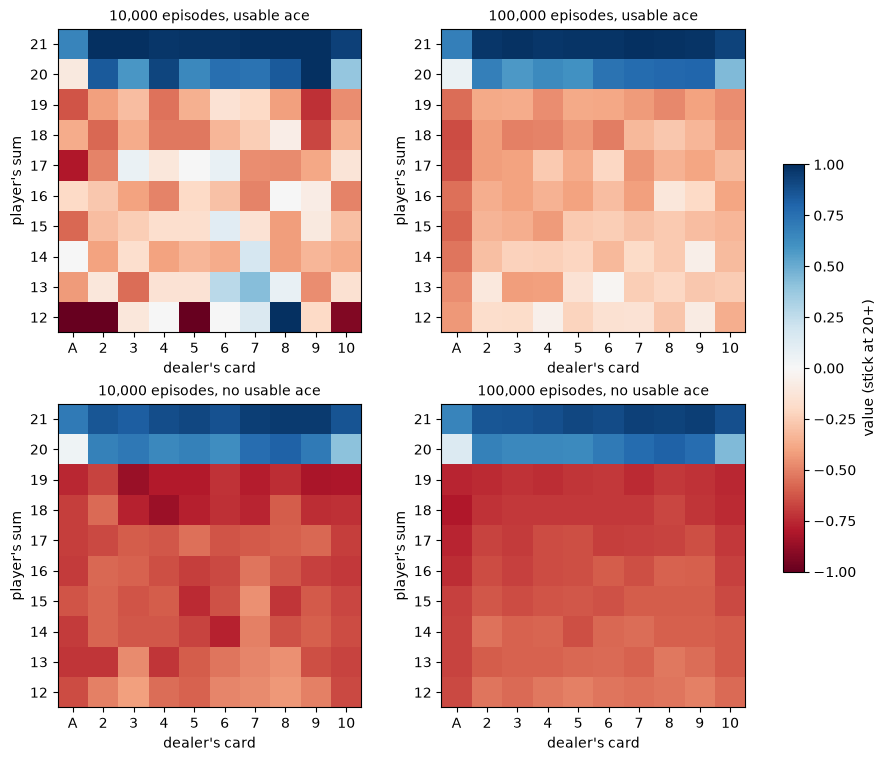

In [13]:
# 方策の表 policy に従って episodes 回遊び、各観測で「その時点から最後までの報酬の合計」を平均して、状態の価値の表を返す
def mc_prediction(env, policy, episodes, gamma=1.0, seed=0):
    values = np.zeros((32, 11, 2))
    counts = np.zeros((32, 11, 2))
    for i in range(episodes):
        obs, info = env.reset(seed=seed if i == 0 else None)
        episode = []
        while True:
            next_obs, reward, terminated, truncated, info = env.step(int(policy[obs]))
            episode.append((obs, reward))
            obs = next_obs
            if terminated or truncated:
                break
        G = 0.0
        for obs, reward in reversed(episode):
            G = gamma * G + reward
            counts[obs] += 1
            values[obs] += (G - values[obs]) / counts[obs]
    return values, counts


fig, axes = plt.subplots(2, 2, figsize=(9, 7.5), layout="constrained")
for col, episodes in enumerate([10_000, 100_000]):
    values, value_counts = mc_prediction(env, policy_20, episodes)
    print(f"{episodes:7,d} 回: 観測 (21, 10, 0) の価値 {values[21, 10, 0]:.3f}、(13, 10, 0) の価値 {values[13, 10, 0]:.3f}、"
          f"合計 12〜21 で平均した回数の合計: A を 11 と数える {value_counts[12:22, 1:11, 1].sum():,.0f}、"
          f"数えない {value_counts[12:22, 1:11, 0].sum():,.0f}")
    for row, usable in enumerate([1, 0]):
        ax = axes[row, col]
        image = ax.imshow(values[12:22, 1:11, usable], origin="lower", cmap="RdBu", vmin=-1, vmax=1,
                          extent=(0.5, 10.5, 11.5, 21.5))
        ax.set_xticks(range(1, 11), [card_label(c) for c in range(1, 11)])
        ax.set_yticks(range(12, 22))
        ax.set_xlabel("dealer's card")
        ax.set_ylabel("player's sum")
        ax.set_title(f"{episodes:,} episodes, " + ("usable ace" if usable else "no usable ace"), fontsize=10)
fig.colorbar(image, ax=axes, shrink=0.6, label="value (stick at 20+)")
fig.savefig(FIGURES / "ch06_values.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 図の上の段が A を 11 と数えている観測、下の段が数えていない観測で、左が 10,000 回、右が 100,000 回で見積もった価値です。青いほど価値が高く、赤いほど低くなります。

どの図でも、合計 20・21 の行はおおむね青く、合計 19 以下の行はおおむね赤みがかっています。10,000 回の上の段は、隣り合うマスで色が大きく違い、まだらです。100,000 回では、上の段も、色の変わり方がなめらかになっています。

出力の数値では、合計 21・ディーラーの札 10 の観測 `(21, 10, 0)` の価値は、10,000 回で 0.862、100,000 回で 0.875、合計 13 の `(13, 10, 0)` は -0.675 と -0.612 です。合計 12〜21 の観測で平均した回数の合計は、A を 11 と数える観測が 2,080 回（10,000 回の場合）と 20,794 回（100,000 回の場合）で、数えない観測（13,442 回と 134,578 回）の 15% ほどです。

A を 11 と数える観測は平均する回数が少なく、10,000 回の時点では、上の段の地図がまだらでした。遊ぶ回数を 10 倍の 100,000 回にすると、なめらかになりました。モンテカルロ法の見積もりは平均なので、回数を増やすほど、偶然によるぶれが小さくなります。

価値が高い合計 20・21 は、この方策が止める合計です。合計 19 以下では、この方策は引き続けます。

## 6. 読む(2)：モンテカルロ制御のサンプル

4-1節のサンプル `mc_control` を読みます。5-2節の `mc_prediction` との違いは、決まった方策ではなく、ε-greedy で行動を選び、観測ごとではなく、観測と行動の組み合わせごとに平均を覚える点です。このように、学んだ Q 値を使って行動を選びながら、方策そのものを良くしていくことを **制御** と呼びます。

### 6-1. 最後まで遊び、記録する

```python
obs, info = env.reset(seed=seed if i == 0 else None)
episode = []
while True:
    if rng.random() < epsilon:  # 探索: でたらめに選ぶ
        action = int(rng.integers(2))
    else:  # 活用: Q 値が最大の行動を選ぶ
        action = greedy_action(q_table, obs, rng)
    next_obs, reward, terminated, truncated, info = env.step(action)
    episode.append((obs, action, reward))
    obs = next_obs
    if terminated or truncated:
        break
```

行動の選び方は、第3〜5章と同じ ε-greedy です。違うのは、このループの中では Q 表を書き換えないことです。選んだ行動と、受け取った報酬を `episode` に記録するだけで、勝負が終わるまで遊びます。

### 6-2. 後ろから報酬の合計を求め、平均する

```python
G = 0.0
for obs, action, reward in reversed(episode):
    G = gamma * G + reward
    counts[obs + (action,)] += 1
    q_table[obs + (action,)] += (G - q_table[obs + (action,)]) / counts[obs + (action,)]
```

勝負が終わったら、記録を後ろから順にたどります。`G` は、その時点から最後までの報酬の合計（割引率 γ をかけたもの）です。後ろから1つずつ `G = gamma * G + reward` と足していくと、各時点の `G` が一度に求まります。Blackjack では途中の報酬が 0 なので、γ = 1.0 のとき、どの時点の `G` も、最後の報酬（+1・0・-1）と同じです。

3行目は、Q 値を、これまでに得た `G` の平均にする書き方です。`counts` 回目の `G` を受け取ったとき、`(G - Q) / counts` だけ動かすと、Q は、それまでの `counts` 個の `G` の平均とちょうど等しくなります。たとえば、1回目に `G = 1` なら Q は 1、2回目に `G = -1` なら Q は 1 + (-1 - 1) / 2 = 0 で、2つの平均です。

第3章の Q学習の書き換えは、`target = reward + gamma * q_table[next_state].max()` のように、次の状態の Q 値の見積もりを目標に使い、学習率 α だけ近づけました。モンテカルロ法は、見積もりを使わずに、実際に最後まで遊んで得た `G` を使います。その代わり、勝負が終わるまで書き換えられません。

### 6-3. Q 表の引き方

`q_table[obs]` の `obs` は、`(11, 10, 0)` のような3つの整数の組です。NumPy の配列を組で引くと、前の3つの軸を指定したことになり、2つの行動の Q 値の配列が返ります。`obs + (action,)` は、組の後ろに行動の番号を足した `(11, 10, 0, 1)` のような組で、1つの Q 値を指します。方策の表 `policy[obs]` も、同じ引き方です。

## 7. 比べる：ルールから計算した答え

Blackjack は、ルールが分かっていれば、最適な方策を計算できます。札の確率（3-2節）と、ディーラーの引き方（17 以上になるまで引く）から、各観測で止めたときと引いたときの報酬の期待値を、場合分けをたどって求めます。第3章の7節の価値反復と同じく、環境の仕組みを使って計算する方法で、モンテカルロ法とは違い、遊ばずに答えが出ます。

次のセルの `solve` は、この計算をする関数です。仕組みを細かく読む必要はありません。答え合わせのための道具として使ってください。方策の表を渡すと、その方策の報酬の期待値も計算できます。

In [14]:
CARD_PROBS = {card: (4 if card == 10 else 1) / 13 for card in range(1, 11)}  # 札は 1〜9 が 1/13 ずつ、10 が 4/13


# A を 1 と数えた合計 total と、A を持っているか has_ace から、手札の合計を返す
def hand_value(total, has_ace):
    return total + 10 if has_ace and total + 10 <= 21 else total


# ディーラーが 17 以上になるまで引いたときの、最後の合計の確率（22 はバースト）
@cache
def dealer_outcomes(total, has_ace):
    value = hand_value(total, has_ace)
    if value >= 17:
        return {min(value, 22): 1.0}
    outcomes = {}
    for card, p in CARD_PROBS.items():
        for final, q in dealer_outcomes(total + card, has_ace or card == 1).items():
            outcomes[final] = outcomes.get(final, 0) + p * q
    return outcomes


# ルールから、各観測の (止める, 引く) の値と、最初に配られた時点からの報酬の期待値を計算する
# policy=None なら値が大きいほうの行動を選び（最適な方策）、方策の表 policy を渡せば、その方策に従う
def solve(policy=None):
    q_exact = np.zeros((32, 11, 2, 2))

    @cache
    def value(total, has_ace, shown):
        player = hand_value(total, has_ace)
        if player > 21:
            return -1.0
        stick = sum(p * (1 if final == 22 or player > final else 0 if player == final else -1)
                    for final, p in dealer_outcomes(shown, shown == 1).items())
        hit = sum(p * value(total + card, has_ace or card == 1, shown) for card, p in CARD_PROBS.items())
        obs = (player, shown, int(has_ace and total + 10 <= 21))
        q_exact[obs] = stick, hit
        action = (0 if stick >= hit else 1) if policy is None else policy[obs]
        return stick if action == 0 else hit

    expected = 0.0
    for first, p1 in CARD_PROBS.items():
        for second, p2 in CARD_PROBS.items():
            for shown, p3 in CARD_PROBS.items():
                if {first, second} == {1, 10}:  # ナチュラル: ディーラーもナチュラルなら引き分け、それ以外は勝ち（+1）
                    hidden_needed = {1: 10, 10: 1}.get(shown)
                    expected += p1 * p2 * p3 * (1 - (CARD_PROBS[hidden_needed] if hidden_needed else 0))
                else:
                    expected += p1 * p2 * p3 * value(first + second, 1 in (first, second), shown)
    return q_exact, expected


q_exact, optimal_expected = solve()
optimal_policy = q_exact.argmax(axis=-1)  # 同じなら止める
print(f"最適な方策の報酬の期待値:      {optimal_expected:.4f}")
for name, policy in [("20 以上で止める", policy_20), ("17 以上で止める", policy_17), ("学習後の方策", learned_policy)]:
    print(f"{name:10s}の報酬の期待値: {solve(policy)[1]:.4f}（3・4節で 100,000 回対戦させた平均は {results[name][0]:.3f}）")

最適な方策の報酬の期待値:      -0.0431
20 以上で止める の報酬の期待値: -0.3501（3・4節で 100,000 回対戦させた平均は -0.355）
17 以上で止める の報酬の期待値: -0.0759（3・4節で 100,000 回対戦させた平均は -0.075）
学習後の方策    の報酬の期待値: -0.0524（3・4節で 100,000 回対戦させた平均は -0.052）


**期待する結果**（上の出力の読み方）: 最適な方策の報酬の期待値は -0.0431 です。この Blackjack では、最適な方策でも、平均すると少し負けます。

ルールから計算した期待値は、「20 以上で止める」方策が -0.3501、「17 以上で止める」方策が -0.0759、学習後の方策が -0.0524 です。3・4節で 100,000 回対戦させた平均（-0.355、-0.075、-0.052）とは、0.005 以内で合っています。学習後の方策と最適な方策の差は 0.0093 です。

`solve` は、`CARD_PROBS`（札の確率）と `dealer_outcomes`（ディーラーの引き方）という、ルールそのものを使っています。4節の `mc_control` は、そのどちらも使わず、`env.step` で遊んだ結果だけから学びました。それでも、次のセルで見るように、200 マスのうち 177 マスで、最適な方策と同じ行動を選んでいます。

なお、`solve` は、ナチュラル（3-1節）の手札では止めるものとして計算しています。4節の学習後の方策も、A を 11 と数えた合計 21 では、どのディーラーの札に対しても止めます（4-3節の右の地図）。

次のセルで、学習後の方策と最適な方策で、行動が違うマスを数え、地図に印を付けます。

合計 12〜21 の 200 マスのうち、学習後の方策と最適な方策の行動が違うマス: 23
観測           学習  最適  ルールから計算した値の差  学習中に平均した回数（STICK / HIT）
(12, 2, 0)     STICK HIT                  0.039      1,569 / 83
(12, 3, 0)     STICK HIT                  0.019      1,448 / 120
(12, 5, 1)     STICK HIT                  0.324        106 / 7
(13, 2, 1)     STICK HIT                  0.339        180 / 16
(13, 3, 0)     HIT   STICK                0.039        609 / 917
(13, 5, 1)     STICK HIT                  0.301        155 / 35
(14, 5, 1)     STICK HIT                  0.279        177 / 14
(14, 6, 1)     STICK HIT                  0.293        171 / 15
(15, 2, 1)     STICK HIT                  0.293        167 / 16
(15, 9, 0)     STICK HIT                  0.072      1,735 / 96
(15, 10, 0)    STICK HIT                  0.040      7,063 / 399
(16, 7, 0)     STICK HIT                  0.061      1,563 / 252
(16, 10, 0)    STICK HIT                  0.006      6,846 / 479
(17, 3, 1)     STICK HIT                  0.146        232 

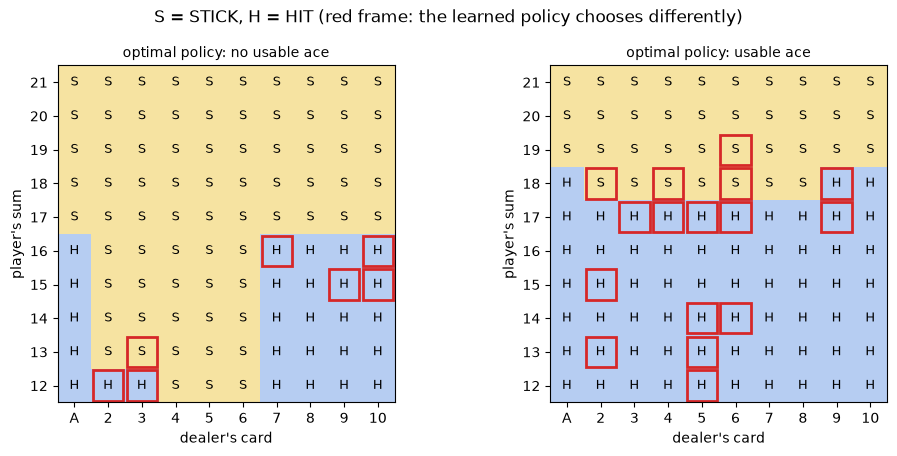

In [15]:
differ = learned_policy != optimal_policy
differ[:12] = False  # 合計 11 以下（図に描かない部分）は数えない
print("合計 12〜21 の 200 マスのうち、学習後の方策と最適な方策の行動が違うマス:", int(differ.sum()))
print("観測           学習  最適  ルールから計算した値の差  学習中に平均した回数（STICK / HIT）")
for player_sum, dealer_card, usable in zip(*np.nonzero(differ)):
    obs = (int(player_sum), int(dealer_card), int(usable))
    gap = abs(q_exact[obs][0] - q_exact[obs][1])
    print(f"{str(obs):14s} {ACTION_NAMES[learned_policy[obs]]:5s} {ACTION_NAMES[optimal_policy[obs]]:5s} "
          f"{gap:20.3f}   {counts[obs][0]:8,.0f} / {counts[obs][1]:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
draw_policy(axes[0], optimal_policy, 0, "optimal policy: no usable ace", marks=differ)
draw_policy(axes[1], optimal_policy, 1, "optimal policy: usable ace", marks=differ)
fig.suptitle("S = STICK, H = HIT (red frame: the learned policy chooses differently)")
fig.tight_layout()
fig.savefig(FIGURES / "ch06_compare.png", dpi=80)
plt.show()

**期待する結果**（上の出力の読み方）: 合計 12〜21 の 200 マスのうち、23 マスで、学習後の方策と最適な方策の行動が違いました。図は最適な方策の地図で、赤い枠が、学習後の方策が違う行動を選ぶマスです。左の地図（A を 11 と数えていない）に 7 マス、右の地図（数えている）に 16 マスあります。

表の右の列は、学習中に、止める・引くのそれぞれで報酬の合計を平均した回数です。23 マスのうち 18 マスでは、どちらかの行動の回数が 100 回未満です（少ないもので 7 回）。残りの 5 マス（`(12, 3, 0)`、`(13, 3, 0)`、`(15, 10, 0)`、`(16, 7, 0)`、`(16, 10, 0)`）は、ルールから計算した2つの行動の値の差が 0.061 以下です（最も小さい `(16, 10, 0)` は 0.006）。

違うマスは、平均した回数が少ないマスか、2つの行動の値の差がもともと小さいマスでした。平均する回数が少ないと、平均は偶然でぶれやすくなります。値の差が小さいマスでは、ぶれが小さくても、大小が入れ替わることがあります。また、学習した Q 値は、学習中の方策（0.1 の確率ででたらめを混ぜる）で遊んだときの見積もりです（5-1節）。最適な方策で遊んだときの値とは、見積もっているもの自体が違うので、ぶれが無くても、ルールから計算した値と大小が食い違うことがあります。違うマスは、右の地図（A を 11 と数えている）のほうが多くなりました。5-2節で見たように、A を 11 と数える観測は、そうでない観測より現れる回数が少なく、上の表でも、右の地図のマスは平均した回数が少なめです。

学習の回数を増やすと、違うマスがどう変わるかを、8-1節で試します。

## 8. 遊んでみる

### 8-1. 学習の回数を変える

学習の回数を 20,000 回と 50,000 回にして学ばせ直し、最適な方策と同じ行動のマスの数と、ルールから計算した報酬の期待値を、4節の 200,000 回と比べます。著者の環境では、このセル全体で 10 秒ほどかかりました。

In [16]:
for episodes in [20_000, 50_000]:
    q, _, _ = mc_control(env, episodes=episodes)
    policy = q.argmax(axis=-1)
    agree = int((policy == optimal_policy)[12:22, 1:11].sum())
    print(f"{episodes:7,d} 回: 最適な方策と同じ行動のマス {agree} / 200、報酬の期待値 {solve(policy)[1]:.4f}")
agree = int((learned_policy == optimal_policy)[12:22, 1:11].sum())
print(f"{200_000:7,d} 回: 最適な方策と同じ行動のマス {agree} / 200、報酬の期待値 {solve(learned_policy)[1]:.4f}（4節）")

 20,000 回: 最適な方策と同じ行動のマス 144 / 200、報酬の期待値 -0.0885


 50,000 回: 最適な方策と同じ行動のマス 157 / 200、報酬の期待値 -0.0686
200,000 回: 最適な方策と同じ行動のマス 177 / 200、報酬の期待値 -0.0524（4節）


**期待する結果**（上の出力の読み方）: 最適な方策と同じ行動のマスは、20,000 回で 144、50,000 回で 157、200,000 回で 177 マス（200 マス中）と増えました。報酬の期待値も、-0.0885、-0.0686、-0.0524 と上がり、最適な方策の -0.0431 に近づいています。

### 8-2. カジノのルールにする

`gym.make("Blackjack-v1", sab=False, natural=True)` にすると、ナチュラルで勝ったときの報酬が 1.5 になります（Gymnasium 1.3.0 のソースによる）。ディーラーの合計も 21 なら、ナチュラルでも引き分けです。カジノのルールに近い設定です。4節のルールで学んだ方策を、そのまま、このルールで 100,000 回対戦させます。

In [17]:
casino = gym.make("Blackjack-v1", sab=False, natural=True)
print("ルールの設定:", casino.spec.kwargs)
for name, policy in [("17 以上で止める", policy_17), ("学習後の方策", learned_policy)]:
    mean, win, draw, lose = play(casino, policy)
    print(f"{name:10s} 報酬の平均 {mean:7.3f}（4節のルールでは {results[name][0]:.3f}）、"
          f"勝ち {win:.1%}、引き分け {draw:.1%}、負け {lose:.1%}")

ルールの設定: {'sab': False, 'natural': True}


17 以上で止める  報酬の平均  -0.057（4節のルールでは -0.075）、勝ち 40.8%、引き分け 10.6%、負け 48.6%


学習後の方策     報酬の平均  -0.034（4節のルールでは -0.052）、勝ち 42.9%、引き分け 8.7%、負け 48.4%


**期待する結果**（上の出力の読み方）: このルールでは、「17 以上で止める」方策の報酬の平均は -0.057、学習後の方策は -0.034 で、4節のルールより、どちらも 0.018 高くなりました。勝ち・引き分け・負けの割合は、4節のルール（3-4節・4-2節）との違いが、どれも 0.3 ポイント以内です。

ナチュラルかどうかは、最初に配られた2枚で決まります。このルールで変わったのは、ナチュラルで勝ったときの報酬（1 → 1.5）と、プレイヤーがナチュラルで、ディーラーがナチュラルでない 21 になったときの扱い（`sab=True` では勝ち、このルールでは引き分け）です。

**やってみよう**:

- 4-1節の `mc_control(env, episodes=200_000)` の `seed` を変えてみてください（例: `mc_control(env, episodes=200_000, seed=1)`）。著者が seed を 0〜4 に変えて試したところ、最適な方策と同じ行動のマスは 177〜191、ルールから計算した報酬の期待値は -0.0474〜-0.0524 で、どの seed でも「17 以上で止める」方策（-0.0759）を上回りました
- `mc_control` の `epsilon` を変えてみてください（例: `epsilon=0.05` や `epsilon=0.3`）。著者が seed 0 の1回だけ試したところ、200,000 回の学習で、0.05 では同じ行動のマスが 177・期待値 -0.0579、0.3 では 180・-0.0553 でした。0.3 では、学習中の最後の 10,000 回の報酬の平均が -0.154 でした（4節の 0.1 では -0.092）
- `solve(threshold_policy(16))[1]` のように、`threshold_policy` の数を変えた方策の期待値を計算して、どの数で止めるのが一番よいかを調べてみましょう

## 9. まとめ

この章では、結果に偶然が入る Blackjack を、モンテカルロ法で解きました。

| したこと | 使ったもの | 節 |
|---|---|---|
| 観測と手札、1回の勝負、決まった方策の成績を見る | `env.unwrapped.player`・`dealer`、`play()` | 3節 |
| モンテカルロ制御で学ばせ、成績・方策の地図・対戦の様子・学習曲線を見る | `mc_control()`、`draw_policy()` | 4節 |
| Q 表と、決まった方策の価値の見積もりを読む | `q_table`・`counts`、`mc_prediction()` | 5節 |
| 最後まで遊んで、報酬の合計の平均で書き換えるコードを読む | `episode`、`G` | 6節 |
| ルールから計算した最適な方策と比べる | `solve()` | 7節 |
| 学習の回数、カジノのルールを変えて試す | `episodes`、`natural` | 8節 |

モンテカルロ法は、勝負を最後まで遊んでから、各時点の「最後までの報酬の合計」を平均して表を書き換えます。第3〜5章の手法と違い、次の状態の Q 値の見積もりは使いません。札の確率やディーラーの引き方といったルールも使わずに、200,000 回の学習で、ディーラーと同じ決まりの方策より勝てるようになり、ルールから計算した最適な方策（-0.0431）に 0.0093 の差まで近づきました。最適な方策と違うマスは、平均した回数が少ないマスか、2つの行動の値の差が小さいマスでした。

これで、第3〜6章の「表で覚える」手法はおしまいです。第7章からは、CartPole のように、観測が連続した数で、表に並べきれない環境を扱う予定です。

- 次に読むもの: 第7章 CartPole（準備中）
- 手法の位置づけを見直したいときは、概要資料の[強化学習](../../overview/rl.md)に戻ってください

<!-- TODO（著者用）: 第7章ができたらリンクにする -->

## 出典

この章は、次の文献・公式の文書と、導入した Gymnasium 1.3.0 の動作（2026-10-10 確認）をもとに、著者の言葉でまとめたものです。逐語の転載ではありません。サンプルのコードは著者が書いたものです。

- R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd edition, MIT Press, 2018（第5章 モンテカルロ法。Blackjack の例と、`sab=True` のルールの出どころ）
- Farama Foundation, Gymnasium Documentation, Blackjack: https://gymnasium.farama.org/environments/toy_text/blackjack/
- Farama Foundation, Gymnasium 1.3.0 のソース `gymnasium/envs/toy_text/blackjack.py`（札の確率、ディーラーの引き方、ナチュラルの扱い、`sab` と `natural` の設定）: https://github.com/Farama-Foundation/Gymnasium/blob/v1.3.0/gymnasium/envs/toy_text/blackjack.py

この章の図と GIF は、著者が matplotlib で描いたものです（Gymnasium の描画の絵は使っていません）。この教科書のライセンスと、使っている第三者のソフトウェアの一覧は、リポジトリの [LICENSE.md](../../LICENSE.md) にあります。